# Load the metrics

In [27]:
import pandas as pd

results_df = pd.read_csv("llm_fairness_results_score.csv", index_col=0)

results_df

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572


# Add the BERTScore column

In [28]:
results_df["BERTScore"] = bert_df["BERTScore_F1"]

results_df

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift,BERTScore
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754,0.858829
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776,0.856058
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949,0.857254
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381,0.855366
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798,0.854524
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572,0.849624


# Compute Overall LLM Score

In [29]:
results_df["Overall Score"] = (
    results_df["ROUGE-1"] +
    results_df["ROUGE-L"] +
    results_df["BLEU"] +
    results_df["BERTScore"]
) / 4

results_df

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift,BERTScore,Overall Score
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754,0.858829,0.345240
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776,0.856058,0.343490
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949,0.857254,0.343661
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381,0.855366,0.336427
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798,0.854524,0.328293
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572,0.849624,0.321519


# Best LLM Model

In [33]:
best_model = ranking.index[0]
best_score = ranking["Overall Score"].iloc[0]

print("Best LLM:", best_model)
print("Overall Score:", best_score)

Best LLM: gpt4o_abstractive_summary
Overall Score: 0.34524015907279976


# Visual comparison of models

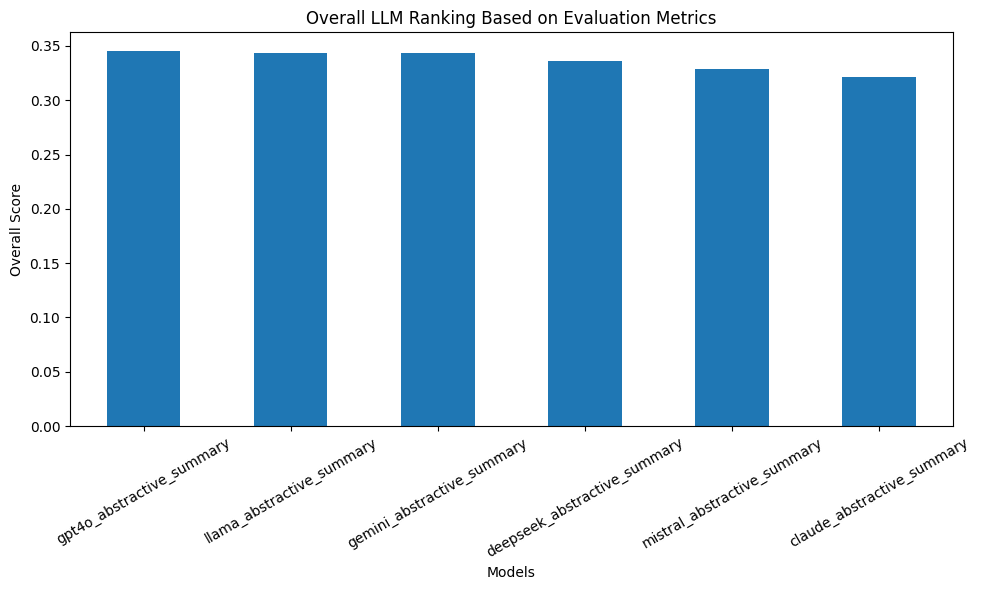

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ranking["Overall Score"].plot(kind="bar")

plt.title("Overall LLM Ranking Based on Evaluation Metrics")
plt.ylabel("Overall Score")
plt.xlabel("Models")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

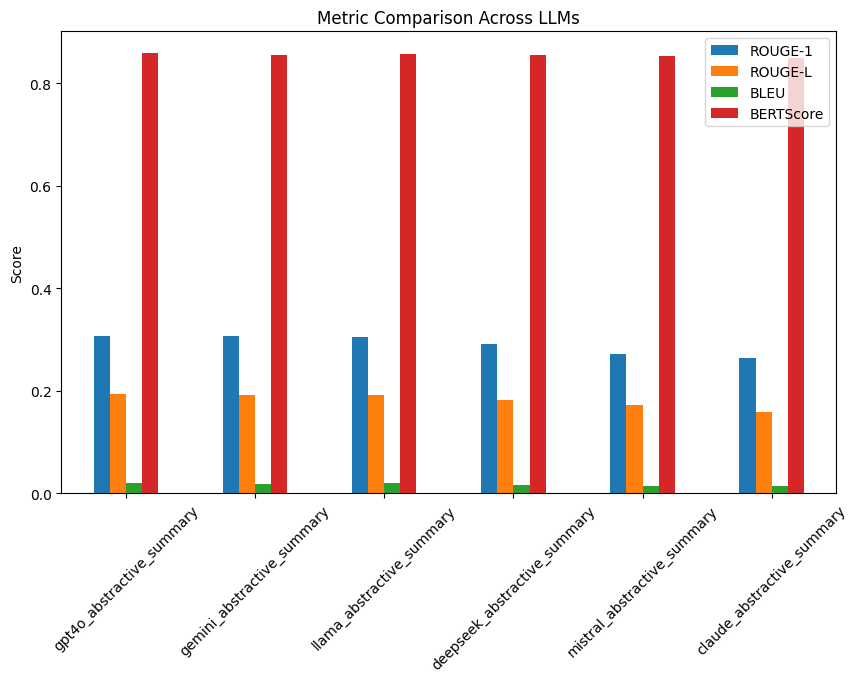

In [35]:
results_df[["ROUGE-1","ROUGE-L","BLEU","BERTScore"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Metric Comparison Across LLMs")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

# 📊 Radar chart comparing all LLMs across ROUGE, BLEU, BERTScore and fairness metrics.

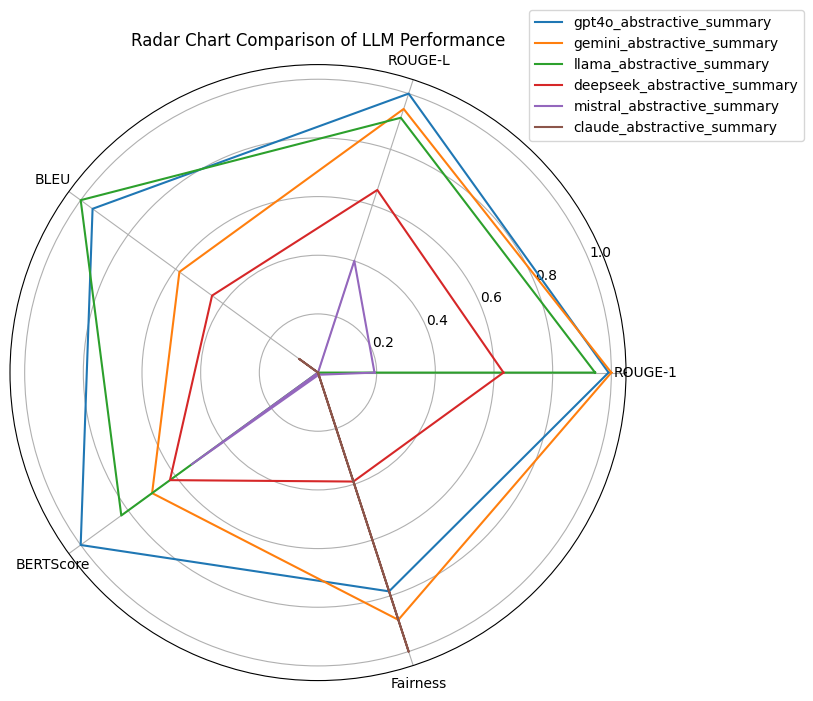

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Select metrics for radar chart
radar_metrics = [
    "ROUGE-1",
    "ROUGE-L",
    "BLEU",
    "BERTScore",
    "Sentiment Shift"
]

radar_df = results_df[radar_metrics].copy()

# Convert sentiment shift to fairness score
radar_df["Fairness"] = 1 - radar_df["Sentiment Shift"]

# Remove original column
radar_df = radar_df.drop(columns=["Sentiment Shift"])

# Normalize metrics so scales match
radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

labels = radar_df.columns
num_metrics = len(labels)

angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for model in radar_df.index:
    
    values = radar_df.loc[model].tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=model)

plt.xticks(angles[:-1], labels)

plt.title("Radar Chart Comparison of LLM Performance")

plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))

plt.show()